# Smart Expense Tracker Application

## Objective

Build a Python-based Smart Expense Tracker Application that helps users log and analyze their spending patterns. The project demonstrates Control Structures, Arrays, OOP, NumPy, Pandas with Datasets, and Matplotlib & Seaborn.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = {
    "Date": [
        "2026-08-01",
        "2026-08-02",
        "2026-08-03",
        "2026-08-05",
        "2026-08-07",
        "2026-08-10",
        "2026-08-12",
        "2026-08-15",
        "2026-08-18",
        "2026-08-20",
        "2026-08-22",
        "2026-08-25",
        "2026-08-27",
        "2026-08-29",
        "2026-08-30"
    ],
    
    "Amount": [
        250,
        120,
        800,
        500,
        300,
        150,
        1200,
        450,
        900,
        350,
        200,
        700,
        400,
        250,
        600
    ],
    
    "Category": [
        "Food",
        "Transport",
        "Utilities",
        "Entertainment",
        "Food",
        "Transport",
        "Shopping",
        "Food",
        "Utilities",
        "Entertainment",
        "Transport",
        "Shopping",
        "Food",
        "Transport",
        "Entertainment"
    ],
    
    "Description": [
        "Lunch",
        "Auto fare",
        "Electricity bill",
        "Movie",
        "Dinner",
        "Bus fare",
        "Clothes",
        "Groceries",
        "Internet bill",
        "Game",
        "Cab fare",
        "Shoes",
        "Dinner",
        "Auto fare",
        "Movie"
    ]
}

df = pd.DataFrame(data)

df.to_csv("expenses.csv", index=False)

df

,Date,Amount,Category,Description
0,2026-08-01,250,Food,Lunch
1,2026-08-02,120,Transport,Auto fare
2,2026-08-03,800,Utilities,Electricity bill
3,2026-08-05,500,Entertainment,Movie
4,2026-08-07,300,Food,Dinner
5,2026-08-10,150,Transport,Bus fare
6,2026-08-12,1200,Shopping,Clothes
7,2026-08-15,450,Food,Groceries
8,2026-08-18,900,Utilities,Internet bill
9,2026-08-20,350,Entertainment,Game


In [4]:
df = pd.read_csv("expenses.csv")

df

,Date,Amount,Category,Description
0,2026-08-01,250,Food,Lunch
1,2026-08-02,120,Transport,Auto fare
2,2026-08-03,800,Utilities,Electricity bill
3,2026-08-05,500,Entertainment,Movie
4,2026-08-07,300,Food,Dinner
5,2026-08-10,150,Transport,Bus fare
6,2026-08-12,1200,Shopping,Clothes
7,2026-08-15,450,Food,Groceries
8,2026-08-18,900,Utilities,Internet bill
9,2026-08-20,350,Entertainment,Game


In [6]:
df.head(10)

,Date,Amount,Category,Description
0,2026-08-01,250,Food,Lunch
1,2026-08-02,120,Transport,Auto fare
2,2026-08-03,800,Utilities,Electricity bill
3,2026-08-05,500,Entertainment,Movie
4,2026-08-07,300,Food,Dinner
5,2026-08-10,150,Transport,Bus fare
6,2026-08-12,1200,Shopping,Clothes
7,2026-08-15,450,Food,Groceries
8,2026-08-18,900,Utilities,Internet bill
9,2026-08-20,350,Entertainment,Game


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         15 non-null     object
 1   Amount       15 non-null     int64 
 2   Category     15 non-null     object
 3   Description  15 non-null     object
dtypes: int64(1), object(3)
memory usage: 612.0+ bytes


In [8]:
df.describe()

,Amount
count,15.000000
mean,478.000000
std,309.335694
min,120.000000
25%,250.000000
50%,400.000000
75%,650.000000
max,1200.000000


In [9]:
df.isnull().sum()

Date           0
Amount         0
Category       0
Description    0
dtype: int64

In [10]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Amount"] = pd.to_numeric(
    df["Amount"],
    errors="coerce"
)

df["Category"] = df["Category"].astype(str).str.strip()

df["Description"] = df["Description"].astype(str).str.strip()

df.dropna(
    subset=["Date", "Amount", "Category", "Description"],
    inplace=True
)

df = df[df["Amount"] >= 0]

df

,Date,Amount,Category,Description
0,2026-08-01,250,Food,Lunch
1,2026-08-02,120,Transport,Auto fare
2,2026-08-03,800,Utilities,Electricity bill
3,2026-08-05,500,Entertainment,Movie
4,2026-08-07,300,Food,Dinner
5,2026-08-10,150,Transport,Bus fare
6,2026-08-12,1200,Shopping,Clothes
7,2026-08-15,450,Food,Groceries
8,2026-08-18,900,Utilities,Internet bill
9,2026-08-20,350,Entertainment,Game


In [14]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [15]:
class ExpenseTracker:
    
    def __init__(self, dataframe):
        self.df = dataframe.copy()
        self.expenses = self.df.to_dict("records")

    def add_expense(self, date, amount, category, description):
        
       
        try:
            date = pd.to_datetime(date)
        except Exception:
            print("Invalid date. Please use YYYY-MM-DD.")
            return
        
      
        try:
            amount = float(amount)
            
            if amount < 0:
                print("Amount cannot be negative.")
                return
                
        except ValueError:
            print("Invalid amount. Please enter a number.")
            return
        
        
        category = str(category).strip()
        
        if category == "":
            print("Category cannot be empty.")
            return
        
      
        description = str(description).strip()
        
        if description == "":
            print("Description cannot be empty.")
            return
        
        new_expense = {
            "Date": date,
            "Amount": amount,
            "Category": category,
            "Description": description
        }
        
        self.expenses.append(new_expense)
        
        self.df = pd.DataFrame(self.expenses)
        
        print("Expense added successfully.")

    def get_summary(self):
        
        if self.df.empty:
            print("No expenses available.")
            return None
        
        amounts = self.df["Amount"].to_numpy()
        
        total_expense = np.sum(amounts)
        average_expense = np.mean(amounts)
        
        print("Total Expense:", total_expense)
        print("Average Expense:", average_expense)
        
        return {
            "total": total_expense,
            "average": average_expense
        }

    def filter_expenses(
        self,
        category=None,
        start_date=None,
        end_date=None,
        amount=None
    ):
        
        filtered_df = self.df.copy()
        
        if category:
            filtered_df = filtered_df[
                filtered_df["Category"].str.lower()
                == str(category).strip().lower()
            ]
        
        if start_date:
            start_date = pd.to_datetime(start_date)
            filtered_df = filtered_df[
                filtered_df["Date"] >= start_date
            ]
        
        if end_date:
            end_date = pd.to_datetime(end_date)
            filtered_df = filtered_df[
                filtered_df["Date"] <= end_date
            ]
        
        if amount is not None:
            amount = float(amount)
            filtered_df = filtered_df[
                filtered_df["Amount"] == amount
            ]
        
        return filtered_df

    def generate_report(self):
        
        if self.df.empty:
            print("No expenses available.")
            return
        
        total = np.sum(
            self.df["Amount"].to_numpy()
        )
        
        average = np.mean(
            self.df["Amount"].to_numpy()
        )
        
        category_summary = (
            self.df
            .groupby("Category")["Amount"]
            .agg(["sum", "mean", "count"])
            .sort_values(
                "sum",
                ascending=False
            )
        )
        
        print("Expense Report")
        print("=" * 50)
        
        print("Total Expense:", total)
        print("Average Expense:", average)
        
        print("\nCategory-wise Summary")
        
        return category_summary

In [16]:
tracker = ExpenseTracker(df)

In [17]:
tracker.add_expense(
    "2026-09-01",
    550,
    "Food",
    "Dinner"
)

Expense added successfully.


In [18]:
tracker.df

,Date,Amount,Category,Description
0,2026-08-01,250.0,Food,Lunch
1,2026-08-02,120.0,Transport,Auto fare
2,2026-08-03,800.0,Utilities,Electricity bill
3,2026-08-05,500.0,Entertainment,Movie
4,2026-08-07,300.0,Food,Dinner
5,2026-08-10,150.0,Transport,Bus fare
6,2026-08-12,1200.0,Shopping,Clothes
7,2026-08-15,450.0,Food,Groceries
8,2026-08-18,900.0,Utilities,Internet bill
9,2026-08-20,350.0,Entertainment,Game


In [19]:
summary = tracker.get_summary()

Total Expense: 7720.0
Average Expense: 482.5


In [21]:
category_spending = (
    tracker.df
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
      )

category_spending

Category
Food             1950.0
Shopping         1900.0
Utilities        1700.0
Entertainment    1450.0
Transport         720.0
Name: Amount, dtype: float64

In [22]:
monthly_spending = (
    tracker.df
    .assign(
        Month=tracker.df["Date"].dt.to_period("M")
    )
    .groupby("Month")["Amount"]
    .sum()
)

monthly_spending

Month
2026-08    7170.0
2026-09     550.0
Freq: M, Name: Amount, dtype: float64

In [23]:
food_expenses = tracker.filter_expenses(
    category="Food"
)

food_expenses

,Date,Amount,Category,Description
0,2026-08-01,250.0,Food,Lunch
4,2026-08-07,300.0,Food,Dinner
7,2026-08-15,450.0,Food,Groceries
12,2026-08-27,400.0,Food,Dinner
15,2026-09-01,550.0,Food,Dinner


In [24]:
date_filtered = tracker.filter_expenses(
    start_date="2026-08-01",
    end_date="2026-08-15"
)

date_filtered

,Date,Amount,Category,Description
0,2026-08-01,250.0,Food,Lunch
1,2026-08-02,120.0,Transport,Auto fare
2,2026-08-03,800.0,Utilities,Electricity bill
3,2026-08-05,500.0,Entertainment,Movie
4,2026-08-07,300.0,Food,Dinner
5,2026-08-10,150.0,Transport,Bus fare
6,2026-08-12,1200.0,Shopping,Clothes
7,2026-08-15,450.0,Food,Groceries


In [25]:
amount_filtered = tracker.filter_expenses(
    amount=500
)

amount_filtered

,Date,Amount,Category,Description
3,2026-08-05,500.0,Entertainment,Movie


In [26]:
report = tracker.generate_report()

report

Expense Report
Total Expense: 7720.0
Average Expense: 482.5

Category-wise Summary


,sum,mean,count
Category,,,
Food,1950.0,390.000000,5
Shopping,1900.0,950.000000,2
Utilities,1700.0,850.000000,2
Entertainment,1450.0,483.333333,3
Transport,720.0,180.000000,4


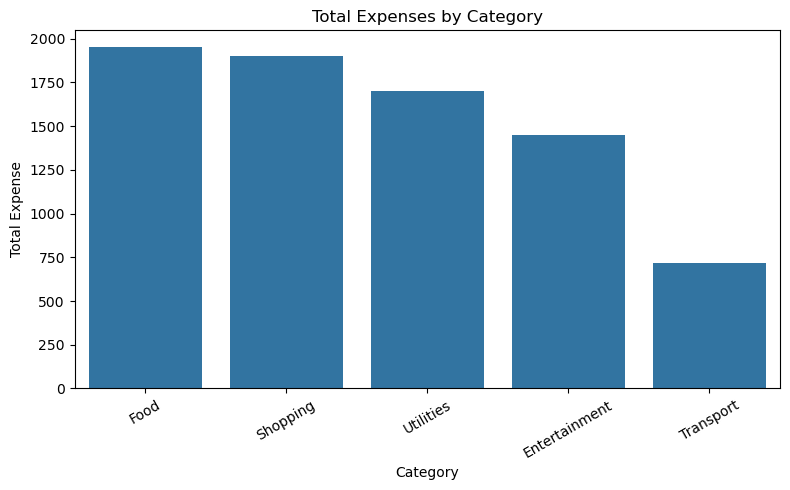

In [27]:
category_data = (
    tracker.df
    .groupby("Category", as_index=False)["Amount"]
    .sum()
    .sort_values(
        "Amount",
        ascending=False
    )
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_data,
    x="Category",
    y="Amount"
)

plt.title("Total Expenses by Category")
plt.xlabel("Category")
plt.ylabel("Total Expense")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

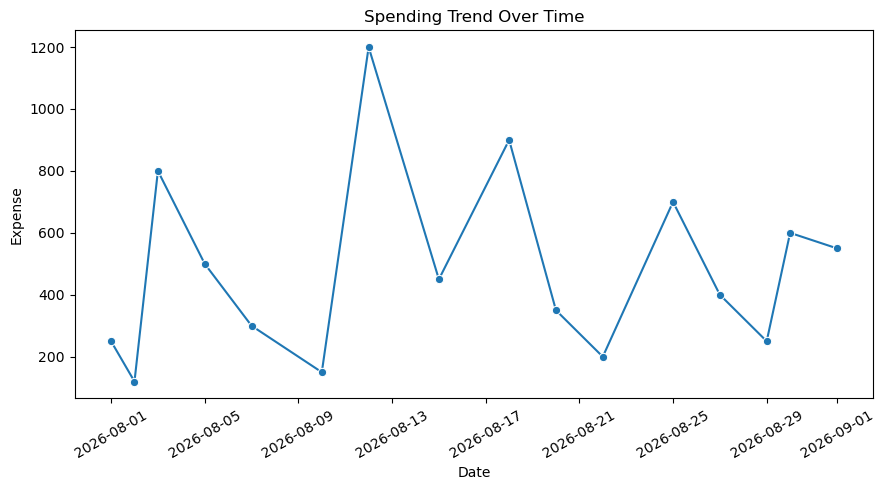

In [28]:
daily_data = (
    tracker.df
    .groupby("Date", as_index=False)["Amount"]
    .sum()
    .sort_values("Date")
)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=daily_data,
    x="Date",
    y="Amount",
    marker="o"
)

plt.title("Spending Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Expense")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

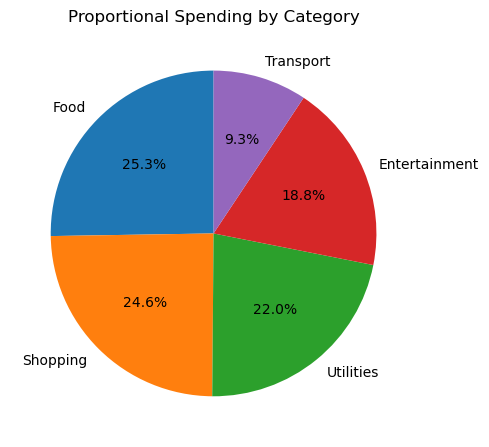

In [32]:
plt.figure(figsize=(5, 5))

plt.pie(
    category_data["Amount"],
    labels=category_data["Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Proportional Spending by Category"
)

plt.tight_layout()
plt.show()

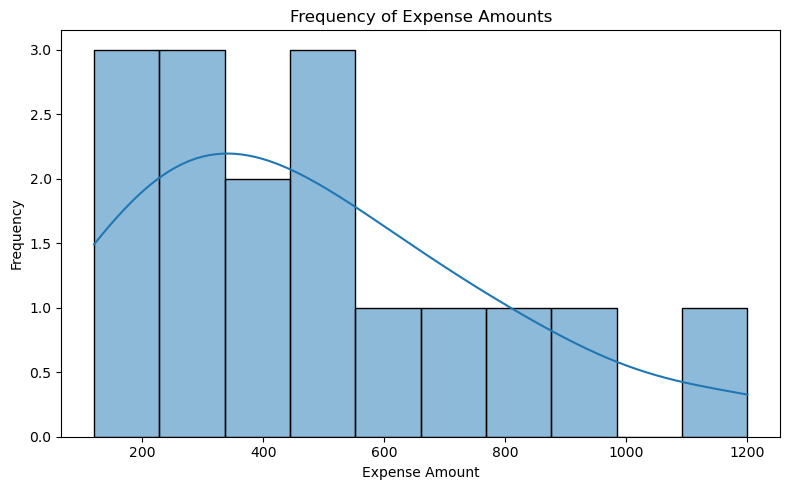

In [30]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=tracker.df,
    x="Amount",
    bins=10,
    kde=True
)

plt.title(
    "Frequency of Expense Amounts"
)

plt.xlabel("Expense Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [31]:
tracker.df

,Date,Amount,Category,Description
0,2026-08-01,250.0,Food,Lunch
1,2026-08-02,120.0,Transport,Auto fare
2,2026-08-03,800.0,Utilities,Electricity bill
3,2026-08-05,500.0,Entertainment,Movie
4,2026-08-07,300.0,Food,Dinner
5,2026-08-10,150.0,Transport,Bus fare
6,2026-08-12,1200.0,Shopping,Clothes
7,2026-08-15,450.0,Food,Groceries
8,2026-08-18,900.0,Utilities,Internet bill
9,2026-08-20,350.0,Entertainment,Game
